Importing Dependencies

In [4]:
!pip install kaggle shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

Loading dataset


In [5]:
df = pd.read_csv('creditcard.csv')

In [6]:
#first three rows
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [7]:
#number ofrowsand columns 
df.shape

(284807, 31)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
#Missing values 
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [39]:
#Normal vs fraud

class_counts = df['Class'].value_counts()
print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


From the above EDA , we know that the fraud percentage is too low.

Let's Visualize Class imnbalance 

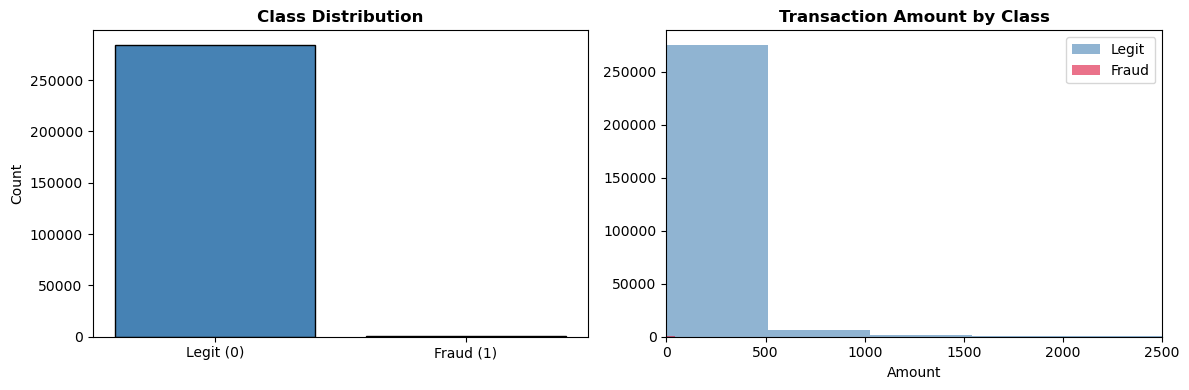

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 - Class imbalance
axes[0].bar(['Legit (0)', 'Fraud (1)'],
            df['Class'].value_counts().values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Plot 2 - Transaction amount by class
axes[1].hist(df[df['Class']==0]['Amount'], bins=50,
             alpha=0.6, color='steelblue', label='Legit')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50,
             alpha=0.6, color='crimson', label='Fraud')
axes[1].set_title('Transaction Amount by Class', fontweight='bold')
axes[1].set_xlabel('Amount')
axes[1].set_xlim(0, 2500)
axes[1].legend()

plt.tight_layout()
plt.show()

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scale Amount and Time
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time']   = scaler.fit_transform(df[['Time']])

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print("\nFraud cases in training set:", y_train.sum())
print("Fraud cases in test set:    ", y_test.sum())

Training set size: (227845, 30)
Test set size:     (56962, 30)

Fraud cases in training set: 394
Fraud cases in test set:     98


SMOTE (Fix the Imbalance)

In [51]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
print("After SMOTE: ", dict(zip(*np.unique(y_train_sm, return_counts=True))))


Before SMOTE: {np.int64(0): np.int64(227451), np.int64(1): np.int64(394)}
After SMOTE:  {np.int64(0): np.int64(227451), np.int64(1): np.int64(227451)}


Before SMOTE: 394 fraud vs 227,451 legit → hugely imbalanced
After SMOTE: 227,451 fraud vs 227,451 legit → perfectly balanced


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")

    # Train on SMOTE data
    model.fit(X_train_sm, y_train_sm)

    # Predict on original test data
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"\nROC-AUC: {roc_auc:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Legit','Fraud'])}")

    results[name] = {
        "model":   model,
        "roc_auc": roc_auc,
        "y_pred":  y_pred,
        "y_proba": y_proba
    }


  Logistic Regression

ROC-AUC: 0.9698

              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


  Random Forest

ROC-AUC: 0.9731

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962


  XGBoost

ROC-AUC: 0.9792

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87

XGBoost wins — as expected! 

Visualize Confusion Matrices

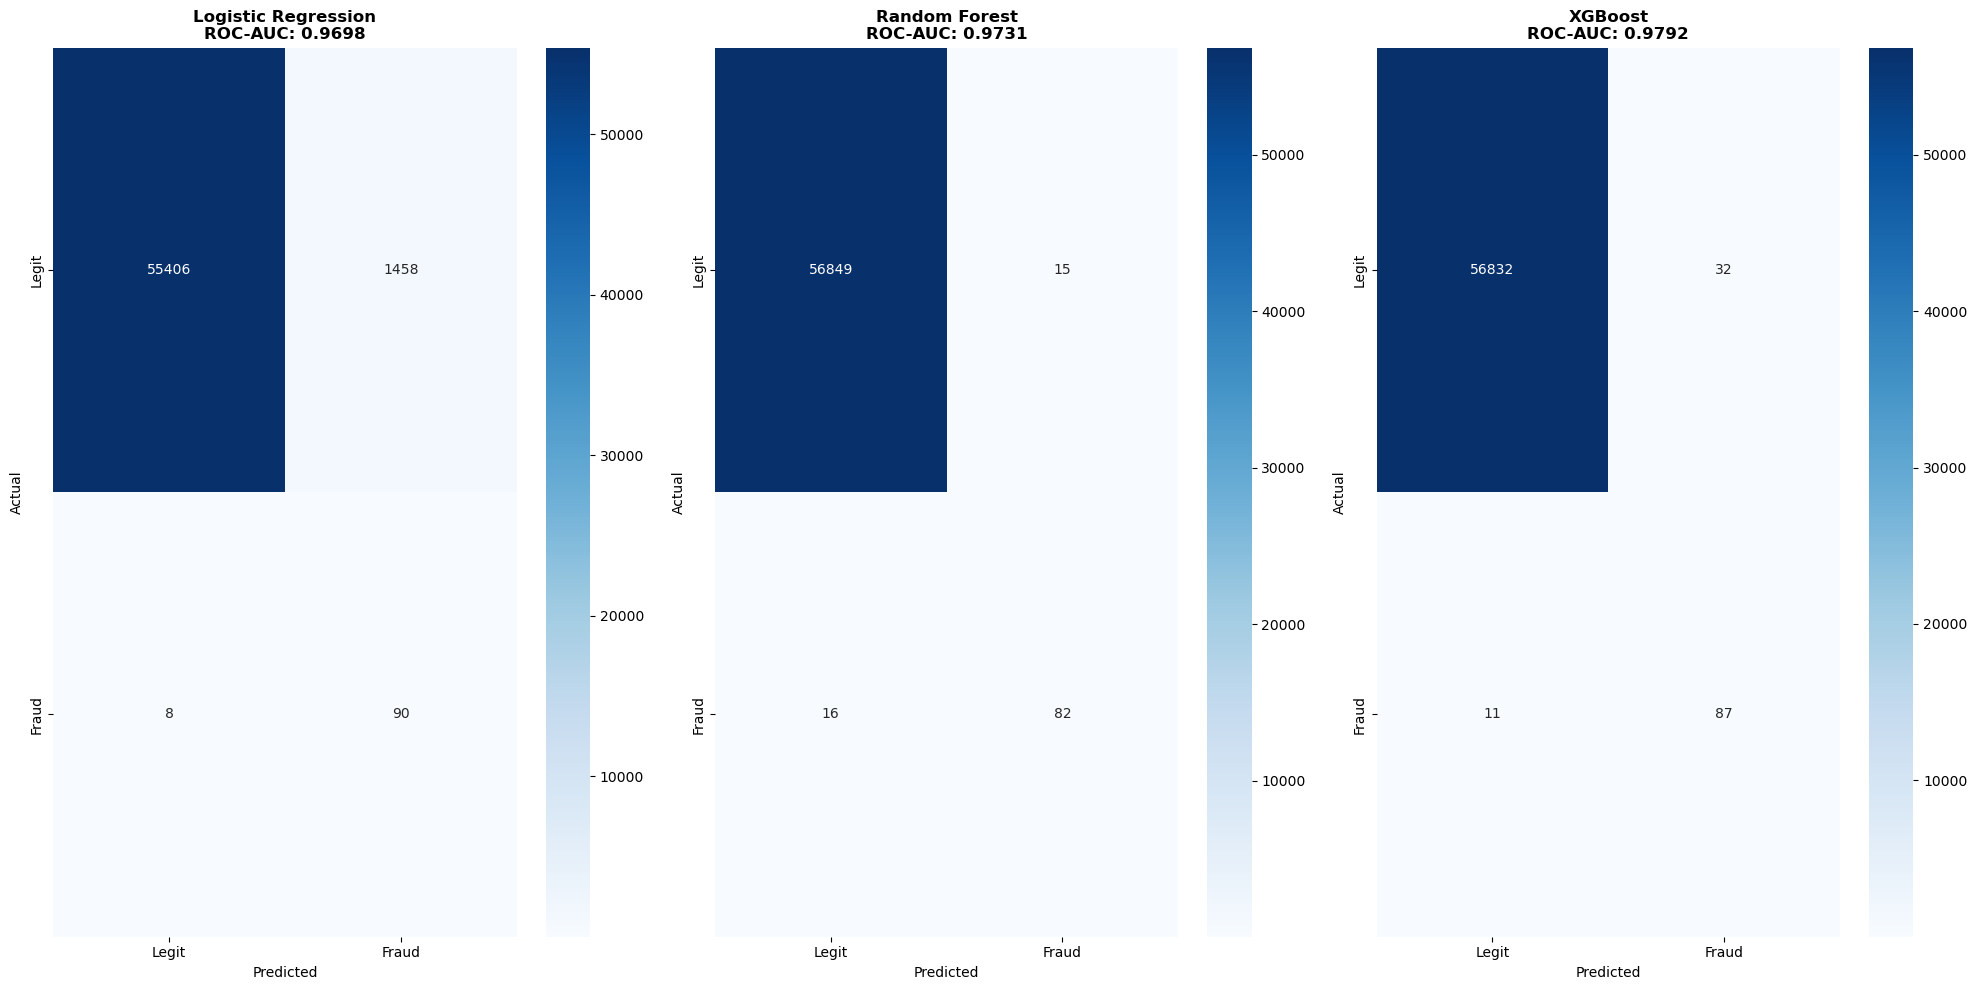

In [57]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["Legit","Fraud"],
                yticklabels=["Legit","Fraud"])
    ax.set_title(f"{name}\nROC-AUC: {res['roc_auc']:.4f}",
                 fontweight='bold')
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


Shap

In [58]:
import shap

# Use XGBoost as it's our best model
best_model = results["XGBoost"]["model"]

# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)

# Use a sample of test data (full set is slow)
X_test_sample = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated successfully!")
print("Shape of SHAP values:", shap_values.shape)

SHAP values calculated successfully!
Shape of SHAP values: (1000, 30)


 Visualize SHAP

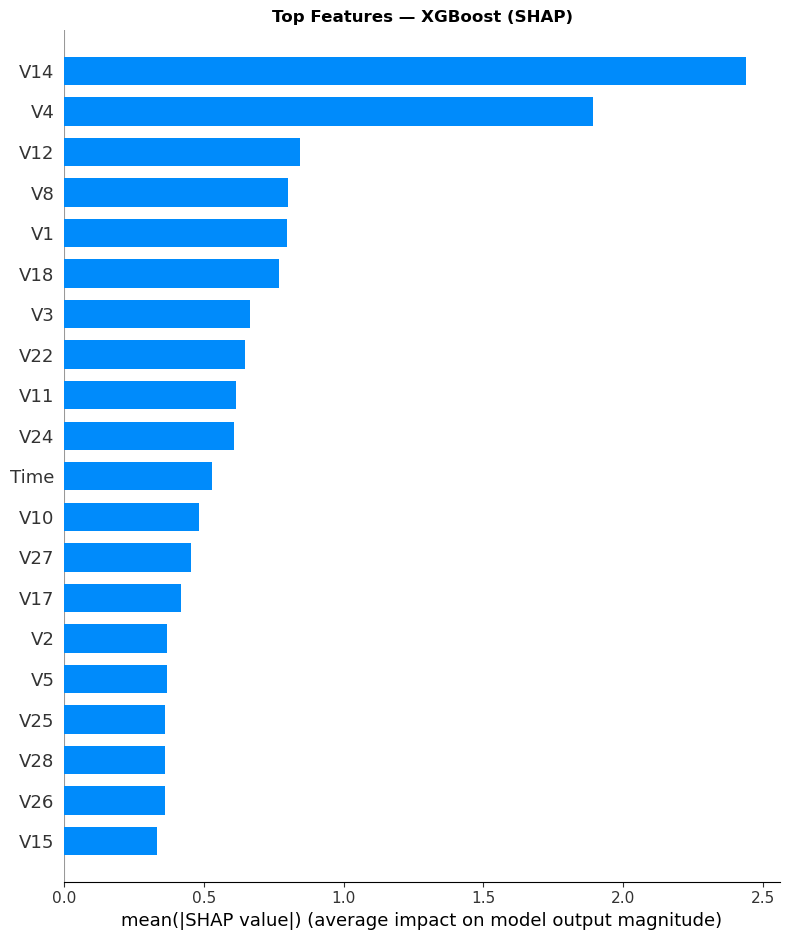

In [59]:
# Summary plot — shows most important features overall
plt.figure()
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("Top Features — XGBoost (SHAP)", fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

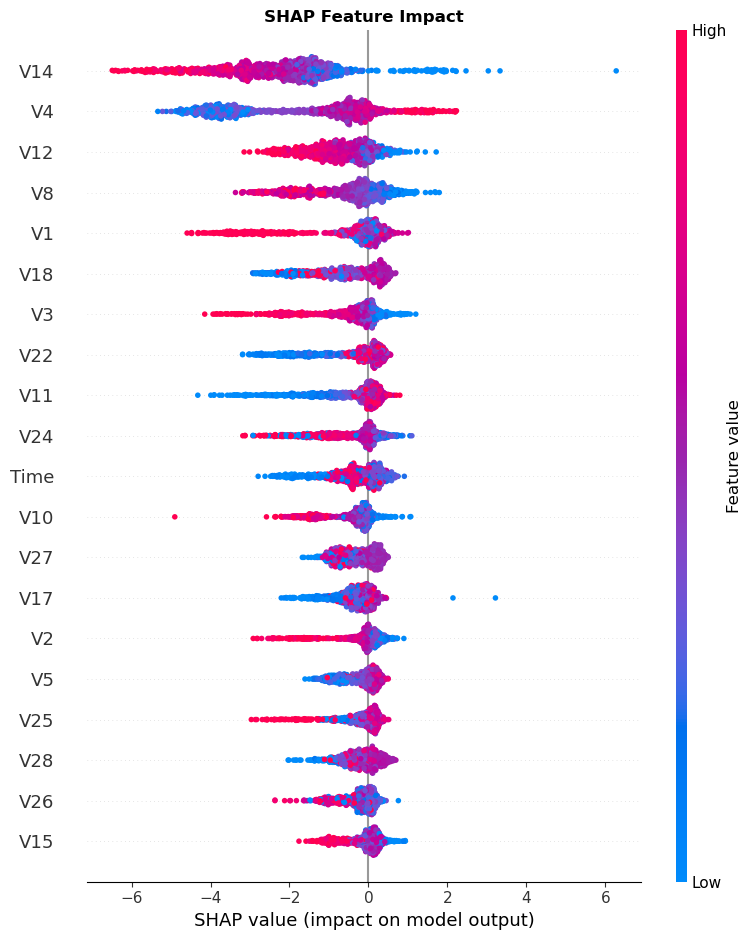

In [60]:
# Dot plot — shows direction of impact per feature
plt.figure()
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Feature Impact", fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dot.png', dpi=150, bbox_inches='tight')
plt.show()